In [ ]:
!wget -O exp-6-1.jpg "https://i.postimg.cc/fL44bkj6/exp-6-1.png"
!wget -O exp-6-2.jpg "https://i.postimg.cc/h41FSDJJ/exp-6-2.png"

In [66]:
import cv2
import numpy as np

In [67]:
from google.colab.patches import cv2_imshow as imshow

In [68]:
img1 = cv2.imread('exp-6-1.jpg', 0)
img2 = cv2.imread('exp-6-2.jpg', 0)

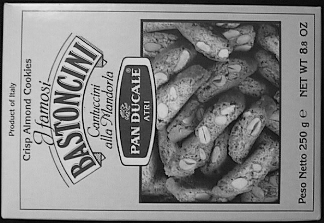

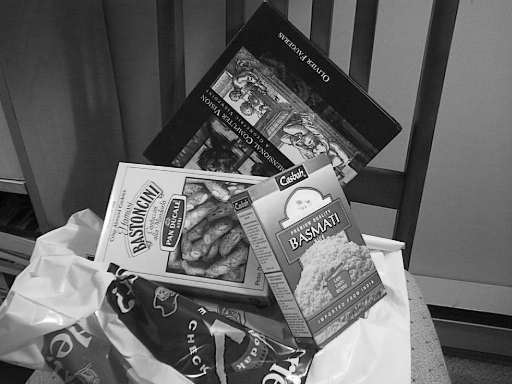

In [57]:
imshow(img1)
imshow(img2)

In [58]:
# Detect keypoints and descriptors using ORB
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

In [59]:
# Configure FLANN matcher for ORB (LSH)
FLANN_INDEX_LSH = 6
index_params = dict(
    algorithm=FLANN_INDEX_LSH,
    table_number=6,
    key_size=12,
    multi_probe_level=1
)
search_params = dict(checks=50)


In [60]:
# Initialize FLANN-based matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

In [61]:
# Match descriptors using KNN
matches = flann.knnMatch(des1, des2, k=2)


In [ ]:
# Apply Lowe’s ratio test
good_matches = []
for m_n in matches:
    if len(m_n) == 2:
        m, n = m_n
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

In [63]:
# Draw and visualize the matches
img_matches = cv2.drawMatches(
    img1, kp1, img2, kp2,
    good_matches, None,
    matchColor=(0, 100, 0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


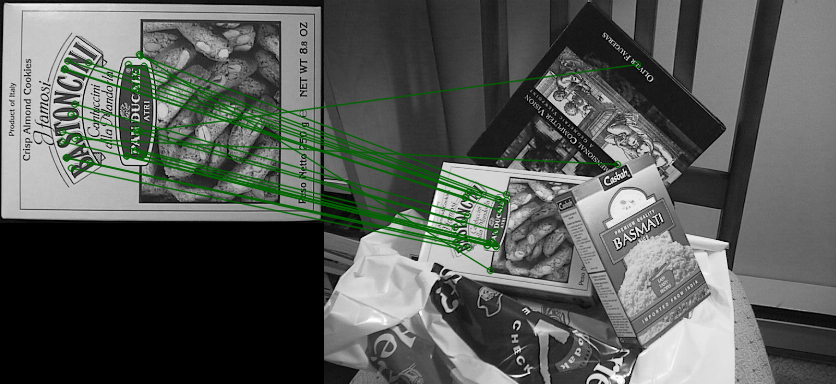

In [64]:
imshow(img_matches)